In [3]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

    

### armar lista credicash

In [4]:


query = """
    select * from cronox.dbo.borrar_efec_negocios
    """
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)



# df_list = df_list.withColumn(
#     'linea_sae',
#     col('linea_sae').cast('int')
# )
# df_list = df_list.withColumn(
#     'q_intentos_telef',
#     col('q_intentos_telef').cast('int')
# )
# df_list = df_list.withColumn(
#     'tea',
#     col('tea').cast('double')
# )


print(df_list.columns)
print(df_list.count())

['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'indice', 'deuda', 'tip_prioridad', 'Zona', 'perfil_ic', 'canal_asignado', 'marca', 'fecha_envio', 'retiro', 'region', 'prioridada', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'ult_estado_tipi_cli', 'ult_descripcion_cli', 'ult_sub_descripcion_cli', 'ult_peso_cli', 'mejor_estado_tipi_telf', 'mejor_descripcion_telf', 'mejor_sub_descripcion_telf', 'mejor_peso_telf']
676080


In [ ]:

# filename='CRE 16.05.5.csv'
# df_bot=cargar_archivo_csv(spark,filename,',',True)
# df_bot.show(2,truncate=False)

+------+---------------------------+---------+------------+-------------------+-------------------------+-------------------------+--------------+---------+------------------------------------------------------------------------------------------------------+-------------+-----------+--------------+------+-------+-----+----+--------+-------+---------+------+------+---------+-----------+-----------------+---------------+--------------+---------+-------+-----------------+----+------------+---------+--------+-------------------------------------------+----------------+---------------+--------------+-------------+-------------------------+--------------------+---------+--------+
|Codigo|Contacto                   |Telefono |Tipificacion|Estado             |Fecha Inicio             |Fecha Fin                |Duracion (seg)|Grabacion|ruta_descarga                                                                                         |Se envio link|Lista negra|Grupo familiar|TIENDA|AGENCIA|F

In [2]:
archivos_cre = [

    archivo

    for archivo in os.listdir(ruta_csv)

    if archivo.startswith('CRE ')
    and archivo.endswith('.csv')
]
dfs = []

for filename in archivos_cre:

    print(f"Leyendo: {filename}")

    df_tmp = cargar_archivo_csv(
        spark,
        filename,
        ',',
        True
    )

    dfs.append(df_tmp)

Leyendo: CRE 16.05.1.csv
Leyendo: CRE 16.05.2.csv
Leyendo: CRE 16.05.3.csv
Leyendo: CRE 16.05.4.csv
Leyendo: CRE 16.05.5.csv
Leyendo: CRE 16.05.6.csv
Leyendo: CRE 16.05.7.csv
Leyendo: CRE 16.05.8.csv
Leyendo: CRE 18.05.1.csv
Leyendo: CRE 18.05.2.csv
Leyendo: CRE 18.05.3.csv
Leyendo: CRE 18.05.4.csv


In [3]:
from functools import reduce

df_bot = reduce(
    lambda df1, df2: df1.unionByName(df2),
    dfs
)

In [4]:
df_bot.count()

32276

In [5]:
df_bot = df_bot.withColumn(

    'Duracion (seg)',

    F.when(
        F.col('Duracion (seg)') == '-',
        None
    ).otherwise(
        F.col('Duracion (seg)')
    ).cast('int')
)

In [85]:
print([row['Duracion (seg)' ] for row in df_bot.select('Duracion (seg)').distinct().collect()])


[31, 78, 34, 28, 27, 26, 12, 91, 22, 111, 1, 52, 13, 6, 16, 3, 20, 40, 5, 19, 92, 41, 154, 15, 43, 37, 17, 9, 72, 35, 4, 55, 8, 39, 23, 49, 7, 69, 63, 10, 38, 80, 25, 24, 29, 214, 21, 98, 60, 32, 11, 83, 14, 123, 42, 2, 201, 149, 30, 99, 67, 46, 0, 18, 36, 53, 44, 218, 164, 48, 227, 59, 50, 45, 181, 121, 62, 90, 75, 170, 33, 71, 85, 103, 163, 64, 88, 51, 116, 66, 146, 139, 97, 58, 119, 47, 177, 259, 94, 96, 61, 127, 114, 195, 56, 105, 204, 106, 147, 135, 124, 89, 65, 155, 210, 76, 122, 157, 93, 206, 234, 158, 101, 57, 54, 107, 130, 129, 102, 79, 172, 115, 126, 81, 86, 175, 77, 73, 156, 95, 145, 198, 131, 74, 134, 132, 112, 176, 150, 68, 302, 215, 138, 141, 110, 144, 104, 133, 231, 84, 216, 118, 281, 120, 179, 100, 304, 184, None]


In [ ]:
df_bot = df_bot.withColumn('fecha inicio',
    F.when(F.col('fecha inicio') == '-',None)
    .otherwise(F.col('fecha inicio'))
)

df_bot = df_bot.withColumn('derivacion',
    F.when(F.col('AGENCIA').isNull(),F.lit('no_venta'))
    .otherwise(F.lit('derivacion'))
)
df_bot = df_bot.withColumn(
        "grupo_valido",
        F.when(F.col("Duracion (seg)").isNull(), "z. Sin dato")
         .when(F.col("Duracion (seg)").between(0, 29), "b. [0 - 29]")
         .when(F.col("Duracion (seg)") >= 30, "d. [>= 30]")
    )
from pyspark.sql import functions as F

df_bot = df_bot.withColumn(
    "seg_duracion",
    
    F.when(F.col("Duracion (seg)").isNull(), "z. Sin dato")
     .when(F.col("Duracion (seg)") == 0,"a. [0]")
     .when(F.col("Duracion (seg)").between(1, 14),"b. [1 - 14]")
     .when(F.col("Duracion (seg)").between(15, 29),"c. [15 - 29]")
     .when(F.col("Duracion (seg)").between(30, 44),"d. [30 - 44]")
     .when(F.col("Duracion (seg)").between(45, 59),"e. [45 - 59]")
     .when(F.col("Duracion (seg)").between(60, 74),"f. [60 - 74]")
     .when(F.col("Duracion (seg)").between(75, 89),"g. [75 - 89]")
     .when(F.col("Duracion (seg)").between(90, 104),"h. [90 - 104]")
     .when(F.col("Duracion (seg)").between(105, 119),"i. [105 - 119]")
     .when(F.col("Duracion (seg)") >= 120,"j. [>= 120]")
)

In [7]:

df_bot = (
    df_bot
    .withColumn(
        "Fecha_Inicio_limpia",
        F.trim(F.col("Fecha Inicio"))
    )
    .withColumn(
        "Fecha_Inicio_limpia",
        F.regexp_replace("Fecha_Inicio_limpia", r"\s*a\.\s*m\.", " AM")
    )
    .withColumn(
        "Fecha_Inicio_limpia",
        F.regexp_replace("Fecha_Inicio_limpia", r"\s*p\.\s*m\.", " PM")
    )
    .withColumn(
        "fecha_inicio_ts",
        F.to_timestamp("Fecha_Inicio_limpia", "d/MM/yyyy hh:mm:ss a")
    )
    .withColumn(
        "fecha_ref",
        F.date_format("fecha_inicio_ts", "yyyy-MM-dd")
    )
    .withColumn(
        "hora_ref",
        F.date_format("fecha_inicio_ts", "HH:mm:ss")
    )
)

In [8]:
from pyspark.sql import functions as F

df_bot = (
    df_bot
    .withColumn(
        "tipi_split",
        F.split(F.col("Tipificacion"), ">")
    )
    .withColumn(
        "nivel_1",
        F.trim(F.get(F.col("tipi_split"), F.lit(0)))
    )
    .withColumn(
        "nivel_2",
        F.trim(F.get(F.col("tipi_split"), F.lit(1)))
    )
    .withColumn(
        "nivel_3",
        F.trim(F.get(F.col("tipi_split"), F.lit(2)))
    )
    .drop("tipi_split")
)

In [14]:
df_bot = df_bot.withColumn(
    "validadcion",
    F.when(F.col("Duracion (seg)").isNull(), "z. Sin dato")
     .when(F.col("Duracion (seg)").between(0, 29),"a. [0 - 29]")
     .when(F.col("Duracion (seg)") >= 30,"b. [>= 30]")
)

In [76]:
df_bot.show()

+------+--------------------+---------+--------------------+-------------------+--------------------+--------------------+--------------+---------+--------------------+-------------+-----------+--------------+------+--------------------+----------+--------+--------+-------+---------+------+------+---------+-------------------+--------------------+---------------+--------------+---------+-------+-----------------+----+-------------+---------+--------------------+--------------------+----------------+---------------+--------------+-------------+--------------------+--------------------+---------+--------+--------------------+-------------------+----------+--------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|Codigo|            Contacto| Telefono|        Tipificacion|             Estado|        fecha inicio|           Fecha Fin|Duracion (seg)|Grabacion|       ruta_descarga|Se envio link|Lista negra|Grupo fa

In [11]:
df_list_filtrada = df_bot.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'bot.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [12]:
print(df_bot.columns)

['Codigo', 'Contacto', 'Telefono', 'Tipificacion', 'Estado', 'fecha inicio', 'Fecha Fin', 'Duracion (seg)', 'Grabacion', 'ruta_descarga', 'Se envio link', 'Lista negra', 'Grupo familiar', 'TIENDA', 'AGENCIA', 'FECHA', 'HORA', 'cl_carga', 'cl_id', 'cl_telf2', 'Region', 'PERFIL', 'cl_base', 'Semaforo', 'MARCA_PD', 'LOTE', 'GRUPO_SEGMENTO', 'FLG_PEARS', 'FLG_URB', 'SITUACION_LABORAL', 'MSI', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'DIRECCION', 'OFERTA_CREDICASH', 'PLAZO_CREDICASH', 'TASA_CREDICASH', 'CME_CREDICASH', 'PRODUCTO_EXTERNO', 'PROPENSION_CREDICASH', 'TIPO_ZONA', 'FRESCURA', 'derivacion', 'grupo_valido', 'seg_duracion', 'Fecha_Inicio_limpia', 'fecha_inicio_ts', 'fecha_ref', 'hora_ref', 'nivel_1', 'nivel_2', 'nivel_3', 'validadcion']


In [89]:
# print(df_bot.columns)
df_bot.select(
'cl_id', 'fecha_ref','hora_ref','Estado', 'Fecha Inicio', 'Duracion (seg)', 'Grabacion', 'TIENDA', 'AGENCIA', 'FECHA', 'HORA', 'Tipificacion','nivel_1','nivel_2','nivel_3','seg_duracion','derivacion'
).filter(F.col('cl_id')=='3487616').show(10,truncate=False)

+-------+----------+--------+-------------------+-------------------------+--------------+---------+------+-------+-----+----+------------+------------+-------+-------+------------+----------+
|cl_id  |fecha_ref |hora_ref|Estado             |Fecha Inicio             |Duracion (seg)|Grabacion|TIENDA|AGENCIA|FECHA|HORA|Tipificacion|nivel_1     |nivel_2|nivel_3|seg_duracion|derivacion|
+-------+----------+--------+-------------------+-------------------------+--------------+---------+------+-------+-----+----+------------+------------+-------+-------+------------+----------+
|3487616|2026-05-18|10:11:16|Buzón / No contesto|18/05/2026 10:11:16 a. m.|NULL          |No       |NULL  |NULL   |NULL |NULL|Contestadora|Contestadora|NULL   |NULL   |z. Sin dato |NULL      |
|3487616|NULL      |NULL    |Buzón / No contesto|NULL                     |NULL          |No       |NULL  |NULL   |NULL |NULL|NULL        |NULL        |NULL   |NULL   |z. Sin dato |NULL      |
+-------+----------+--------+------

In [17]:
df_list_filtrada = df_bot.select(
'cl_id', 'fecha_ref','hora_ref','Estado', 'Fecha Inicio', 'Duracion (seg)', 'Grabacion', 'TIENDA', 'AGENCIA', 'FECHA', 'HORA', 'Tipificacion','nivel_1','nivel_2','nivel_3','seg_duracion','derivacion','validadcion'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'bot_01.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [ ]:
['Codigo', 'Contacto', 'Telefono', 'Tipificacion', 'Estado', 'fecha inicio', 'Fecha Fin', 'Duracion (seg)', 'Grabacion', 'ruta_descarga', 'Se envio link', 'Lista negra', 'Grupo familiar', 'TIENDA', 'AGENCIA', 'FECHA', 'HORA', 'cl_carga', 'cl_id', 'cl_telf2', 'Region', 'PERFIL', 'cl_base', 'Semaforo', 'MARCA_PD', 'LOTE', 'GRUPO_SEGMENTO', 'FLG_PEARS', 'FLG_URB', 'SITUACION_LABORAL', 'MSI', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'DIRECCION', 'OFERTA_CREDICASH', 'PLAZO_CREDICASH', 'TASA_CREDICASH', 'CME_CREDICASH', 'PRODUCTO_EXTERNO', 'PROPENSION_CREDICASH', 'TIPO_ZONA', 'FRESCURA', 'derivacion', 'grupo_valido', 'seg_duracion', 'Fecha_Inicio_limpia', 'fecha_inicio_ts', 'fecha_ref', 'hora_ref', 'nivel_1', 'nivel_2', 'nivel_3', 'validadcion']


In [6]:
df_bot.groupBy('AGENCIA') \
    .count() \
   .orderBy('AGENCIA') \
    .show(30, truncate=False)


+----------------------------+-----+
|AGENCIA                     |count|
+----------------------------+-----+
|NULL                        |32224|
|CARSA MOTOS EXPRESS_CHIMBOTE|1    |
|CARSA MOTOS_IQUITOS         |1    |
|CARSA MOTOS_PUCALLPA        |1    |
|CARSA MOTOS_PUERTO MALDONADO|1    |
|CARSA_ABANCAY               |2    |
|CARSA_AREQUIPA NORTE        |1    |
|CARSA_AYACUCHO              |1    |
|CARSA_CAJABAMBA             |1    |
|CARSA_CHICLAYO              |6    |
|CARSA_COMAS BELAUNDE        |1    |
|CARSA_HUAMACHUCO            |2    |
|CARSA_HUANCAYO              |1    |
|CARSA_HUARMEY               |1    |
|CARSA_HUAYCAN               |1    |
|CARSA_JAEN                  |1    |
|CARSA_JUANJUI CENTRO        |2    |
|CARSA_JULIACA               |1    |
|CARSA_LA UNION              |1    |
|CARSA_NAZCA                 |2    |
|CARSA_PAITA                 |2    |
|CARSA_PIURA                 |1    |
|CARSA_SULLANA               |1    |
|CARSA_TAMBOGRANDE CENTRO    |3    |
|

In [ ]:
df_bot.groupBy('seg_duracion') \
    .count() \
   .orderBy('seg_duracion') \
    .show(30, truncate=False)


print("Total registros:", df_bot.count())

+--------------+-----+
|seg_duracion  |count|
+--------------+-----+
|a. [0]        |25   |
|b. [1 - 15]   |8723 |
|c. [16 - 30]  |1610 |
|d. [31 - 45]  |648  |
|e. [46 - 60]  |137  |
|f. [106 - 120]|20   |
|f. [121 - 135]|21   |
|f. [136 - 150]|10   |
|f. [151 - 165]|11   |
|f. [166 - 180]|7    |
|f. [181 - 195]|5    |
|f. [196 - 210]|5    |
|f. [211 - 225]|4    |
|f. [226 - 240]|3    |
|f. [256 - 270]|1    |
|f. [271 - 285]|1    |
|f. [301 - 315]|2    |
|f. [61 - 75]  |72   |
|f. [76 - 90]  |45   |
|f. [91 - 105] |43   |
|z. null       |18277|
+--------------+-----+

Total registros: 29670


In [ ]:
print([row['df_bot' ] for row in df_bot.select('df_bot').distinct().collect()])


['CARSA MOTOS_IQUITOS', 'CARSA_CHICLAYO', 'CARSA_SULLANA', 'MARCIMEX_ICA', 'CARSA_HUAYCAN', 'GMG_CARABAYLLO', 'CARSA_PIURA', 'CARSA MOTOS_PUCALLPA', 'CARSA_VIRU', 'CARSA_CAJABAMBA', 'CARSA_HUANCAYO', 'GMG_PUENTE PIEDRA', 'MARCIMEX_CAJAMARCA', 'CARSA_TAMBOGRANDE CENTRO', 'CARSA_JULIACA', 'CARSA_JAEN', 'MOTO GO_CUSCO', 'GMG_VES', 'CARSA MOTOS EXPRESS_CHIMBOTE', 'CARSA_HUAMACHUCO', 'CARSA_COMAS BELAUNDE', 'CARSA_ABANCAY', 'CARSA_PAITA', 'CARSA_YURIMAGUAS', 'CARSA_AREQUIPA NORTE', 'CARSA_TRUJILLO', 'CARSA_JUANJUI CENTRO', 'CARSA_AYACUCHO', 'GMG_VMT', 'CARSA_HUARMEY', 'CARSA_LA UNION', 'MOTO GO_JAEN', 'CARSA_NAZCA', None]


In [42]:
from pyspark.sql import functions as F

df_bot = df_bot.withColumn(

    'seg_duracion',

    F.when(
        F.col('Duracion (seg)').isNull(),
        'z. null'
    ).when(
        F.col('Duracion (seg)') == 0,
        'a. [0]'
    ).otherwise(

        F.concat(

            F.when(
                (((F.col('Duracion (seg)') - 1) / 15).cast('int') + 1) == 1,
                F.lit('b. ')
            ).when(
                (((F.col('Duracion (seg)') - 1) / 15).cast('int') + 1) == 2,
                F.lit('c. ')
            ).when(
                (((F.col('Duracion (seg)') - 1) / 15).cast('int') + 1) == 3,
                F.lit('d. ')
            ).when(
                (((F.col('Duracion (seg)') - 1) / 15).cast('int') + 1) == 4,
                F.lit('e. ')
            ).otherwise(
                F.lit('f. ')
            ),

            F.lit('['),

            (
                (((F.col('Duracion (seg)') - 1) / 15).cast('int') * 15) + 1
            ).cast('int'),

            F.lit(' - '),

            (
                (((F.col('Duracion (seg)') - 1) / 15).cast('int') * 15) + 15
            ).cast('int'),

            F.lit(']')
        )
    )
)

In [ ]:
['Codigo', 'Contacto', 'Telefono', 'Tipificacion', 'Estado', 'Fecha Inicio', 'Fecha Fin', 'Duracion (seg)', 'Grabacion', 'ruta_descarga', 'Se envio link', 'Lista negra', 'Grupo familiar', 'TIENDA', 'AGENCIA', 'FECHA', 'HORA', 'cl_carga', 'cl_id', 'cl_telf2', 'Region', 'PERFIL', 'cl_base', 'Semaforo', 'MARCA_PD', 'LOTE', 'GRUPO_SEGMENTO', 'FLG_PEARS', 'FLG_URB', 'SITUACION_LABORAL', 'MSI', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'DIRECCION', 'OFERTA_CREDICASH', 'PLAZO_CREDICASH', 'TASA_CREDICASH', 'CME_CREDICASH', 'PRODUCTO_EXTERNO', 'PROPENSION_CREDICASH', 'TIPO_ZONA', 'FRESCURA']du

['Codigo', 'Contacto', 'Telefono', 'Tipificacion', 'Estado', 'Fecha Inicio', 'Fecha Fin', 'Duracion (seg)', 'Grabacion', 'ruta_descarga', 'Se envio link', 'Lista negra', 'Grupo familiar', 'TIENDA', 'AGENCIA', 'FECHA', 'HORA', 'cl_carga', 'cl_id', 'cl_telf2', 'Region', 'PERFIL', 'cl_base', 'Semaforo', 'MARCA_PD', 'LOTE', 'GRUPO_SEGMENTO', 'FLG_PEARS', 'FLG_URB', 'SITUACION_LABORAL', 'MSI', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'DIRECCION', 'OFERTA_CREDICASH', 'PLAZO_CREDICASH', 'TASA_CREDICASH', 'CME_CREDICASH', 'PRODUCTO_EXTERNO', 'PROPENSION_CREDICASH', 'TIPO_ZONA', 'FRESCURA']


In [22]:
df_bot.show(2, truncate=False)

+------+-----------------------------------+---------+------------+-------------------+-------------------------+-------------------------+--------------+---------+------------------------------------------------------------------------------------------------------+-------------+-----------+--------------+------+-------+-----+----+--------+-------+---------+------+------+---------+-----------+-----------------+---------------+--------------+---------+-------+-----------------+----+------------+---------+-------------------------+-----------------------------------+----------------+---------------+--------------+-------------+-------------------------+--------------------+---------+--------+
|Codigo|Contacto                           |Telefono |Tipificacion|Estado             |Fecha Inicio             |Fecha Fin                |Duracion (seg)|Grabacion|ruta_descarga                                                                                         |Se envio link|Lista negra|Grupo 

In [5]:
print(df_bot.columns)

['Codigo', 'Contacto', 'Telefono', 'Tipificacion', 'Estado', 'Fecha Inicio', 'Fecha Fin', 'Duracion (seg)', 'Grabacion', 'ruta_descarga', 'Se envio link', 'Lista negra', 'Grupo familiar', 'TIENDA', 'AGENCIA', 'FECHA', 'HORA', 'cl_carga', 'cl_id', 'cl_telf2', 'Region', 'PERFIL', 'cl_base', 'Semaforo', 'MARCA_PD', 'LOTE', 'GRUPO_SEGMENTO', 'FLG_PEARS', 'FLG_URB', 'SITUACION_LABORAL', 'MSI', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'DIRECCION', 'OFERTA_CREDICASH', 'PLAZO_CREDICASH', 'TASA_CREDICASH', 'CME_CREDICASH', 'PRODUCTO_EXTERNO', 'PROPENSION_CREDICASH', 'TIPO_ZONA', 'FRESCURA']


In [ ]:
['Codigo', 'Contacto', 'Telefono', 'Tipificacion', 'Estado', 'Fecha Inicio', 'Fecha Fin', 'Duracion (seg)', 'Grabacion', 'ruta_descarga', 'Se envio link', 'Lista negra', 'Grupo familiar', 'TIENDA', 'AGENCIA', 'FECHA', 'HORA', 'cl_carga', 'cl_id', 'cl_telf2', 'Region', 'PERFIL', 'cl_base', 'Semaforo', 'MARCA_PD', 'LOTE', 'GRUPO_SEGMENTO', 'FLG_PEARS', 'FLG_URB', 'SITUACION_LABORAL', 'MSI', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'DIRECCION', 'OFERTA_CREDICASH', 'PLAZO_CREDICASH', 'TASA_CREDICASH', 'CME_CREDICASH', 'PRODUCTO_EXTERNO', 'PROPENSION_CREDICASH', 'TIPO_ZONA', 'FRESCURA']durac

In [7]:
df_bot.select('cl_id','Duracion (seg)').show()

+-------+--------------+
|  cl_id|Duracion (seg)|
+-------+--------------+
|3575777|             -|
|3567127|           195|
|3576681|             -|
|3564026|            10|
|3550064|             -|
|3556131|             9|
|3565147|            16|
|3576615|             2|
|3568915|             -|
|3527874|             -|
|3561561|             8|
|3579900|             -|
|3524554|             2|
|3567401|             -|
|3540920|             2|
|3550128|             -|
|3576188|             2|
|3526566|             2|
|3592048|             -|
|3583469|             2|
+-------+--------------+
only showing top 20 rows


In [ ]:
['cl_id', 'cabecera_carga', 'dni_cliente', 'contacto', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'retiro', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro4', 'estado_venta', 'lote_01']regi


In [ ]:
df_list.filter(F.col('fecha_llamada')=='2026-')

In [ ]:
df_list.filter(F.col('fecha_llamada')).groupBy('region') \
    .count() \
    .orderBy('region') \
    .show(30, truncate=False)

+-------------+-----+
|fecha_llamada|count|
+-------------+-----+
|NULL         |29046|
|2026-05-02   |2736 |
|2026-05-04   |6383 |
|2026-05-05   |10232|
|2026-05-06   |13660|
|2026-05-07   |9122 |
|2026-05-08   |10994|
|2026-05-09   |9456 |
|2026-05-11   |6046 |
|2026-05-12   |10441|
|2026-05-13   |11046|
|2026-05-14   |9215 |
+-------------+-----+



In [ ]:
df_list.groupBy('producto_externo') \
    .count() \
    .orderBy('producto_externo') \
    .show(30, truncate=False)

In [ ]:
df_list.dropDuplicates(['dni_cliente']).groupBy('lote_01') \
    .count() \
    .orderBy('lote_01') \
    .show(30, truncate=False)

print([row['lote_01' ] for row in df_list.select('lote_01').distinct().collect()])


+-----------------+-----+
|lote_01          |count|
+-----------------+-----+
|01.INVENTARIO    |76312|
|02. FRESCURA CERO|4536 |
|03.BASE CLIENTE  |11965|
|04.BASE REGULAR  |18315|
+-----------------+-----+



In [18]:
df_list_filtrada = df_parte_2.select(
    'cabecera_carga'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'credicash_parte_2.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [10]:
df_list.groupBy('tipo_telf') \
    .count() \
    .orderBy('tipo_telf') \
    .show(30, truncate=False)

+---------+------+
|tipo_telf|count |
+---------+------+
|cel01    |128293|
|cel02    |86    |
|cel08    |15487 |
|cel09    |9035  |
+---------+------+



In [ ]:
lote_01=['04.BASE REGULAR', '02. FRESCURA CERO', '03.BASE CLIENTE', '01.INVENTARIO', '05. REINGRESO']
# lote_01=['04.BASE REGULAR', '02. FRESCURA CERO', '03.BASE CLIENTE', '01.INVENTARIO', '05. REINGRESO']
propension_credicash=['1','2']


In [9]:
perfil=['O1', 'O2',  'D2']


In [34]:
df_list.count()

2680

In [3]:
mejor15_descripcion_telf=['DERIVA A CASILLA DE VOZ',
 'TELÉFONO APAGADO',
 'CORTA LLAMADA',
 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO',
 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES',
 'YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD',
 'NO CONOCE ALFIN BANCO',
 'NO BRINDARÁ INFORMACIÓN A TITULAR',
 'BRINDARÁ INFORMACIÓN A TITULAR',
 'ALFIN NO TIENE SUCURSAL CERCA',
 'DISCADOR',
 'NO CONTESTAN',
 ]


In [ ]:
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'retiro', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro4', 'lote_01']prope


In [15]:
spark.stop()

In [20]:
df_list_filtrada = df_filtrado.select(
    'cabecera_carga','region', 'tienda_ir'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'df_parte_3.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [6]:
# print([row['mejor_estado_tipi_cli' ] for row in df_list.select('mejor_estado_tipi_cli').distinct().collect()])
mejor_estado_tipi_cli=['CONTACTO EFECTIVO CON TITULAR', ]

In [19]:

df_filtrado = df_list.filter(
    
    # ((F.col('mejor_estado_tipi_cli').isin(mejor_estado_tipi_cli)) ) &
    # ((F.col('mejor_estado_tipi_cli').isin(mejor_estado_tipi_cli)) | (F.col('mejor_estado_tipi_cli').isNull())) &
    ((F.col('mejor_descripcion_cli').isin(mejor15_descripcion_telf)) | (F.col('mejor_descripcion_cli').isNull())) &
    ((F.col('mejor15_descripcion_telf').isin(mejor15_descripcion_telf)) | (F.col('mejor15_descripcion_telf').isNull())) &
    ((F.col('fecha_llamada')<'2026-05-18') | (F.col('mejor15_descripcion_telf').isNull())) &
        # ((F.col('grupo_segmento').isin('R')))

    ((F.col('fecha_llamada').isNull()))&
    # # (F.col('perfil').isin(perfil))&    
    (
        (F.col('tipo_telf')=='cel01')|
        (F.col('tipo_telf')=='cel02')|
        (F.col('tipo_telf')=='cel08')|
        (F.col('tipo_telf')=='cel09')|
        (F.col('tipo_telf')=='cel10')
    )&
        (F.col('perfil').isin('D0','D1','D2'))&

        (F.col('frescura').isin('3'))&
        # (F.col('propension_credicash').isin('1','2','3','4'))&
        
    #     # (~(F.col('region').isin([ 'R7', 'R4'])))&
        # ((F.col('marca_pd').isin('MES, PLD PEERS','NO MES, PLD PEERS')))&
    
    # (
    #    (F.col('fecha_llamada').isNull())

    # )&  
    # (
    #     ((F.col('lote_01').isin('03.BASE CLIENTE','01.INVENTARIO'))&(F.col('frescura').isin('0','1')))|
    #     ((F.col('frescura').isin('0')))
    # ) &    
    # ((F.col('fecha_llamada').isNull()))

    ((F.col('retiro').isin('no aplica')))

).orderBy(F.col('oferta_max').desc())

print(df_filtrado.count())
print(df_filtrado.columns)

18980
['cl_id', 'cabecera_carga', 'dni_cliente', 'contacto', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'retiro', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'se

In [18]:
df_filtrado.groupBy('frescura') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+--------+-----+
|frescura|count|
+--------+-----+
|3       |18980|
|2       |4778 |
|1       |1003 |
|4       |897  |
|0       |33   |
+--------+-----+



In [16]:
df_01=df_filtrado.select('dni_cliente')

In [ ]:
overwrite_table_SQL(df_01,)

In [17]:
overwrite_table_SQL(spark,df_01,f'validar_dni_credicash',server_sa,user_sa,pwd_sa,'CRONOX')


In [27]:
df_filtrado.show()

+--------------------+-----------+---------+-------+-----------+--------------------+-------------------+------------------+----------------+---------+-----------+----------------+---------------+-----------+----------+----------+--------------+------------+-------------+-----------+----------------+--------------+---------------+-------------+------+-----+----+--------------+---------------+---------+----+-------------+----------+-------+----------+-------+-----------------+------+--------------------+-----------------+--------------+--------------------+--------------+--------------------+------------------+--------------------+--------------------+------------+-------+---------+------+---------+----+----------------+------------+--------------+--------+----------+--------------------+------------------+------------------+----------------+---------------+-----------------+--------+-----------------+-------------+-------------+---------+---------------------+---------------------+----

In [10]:
print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])


['DERIVA A CASILLA DE VOZ', 'TELÉFONO APAGADO', 'CORTA LLAMADA', 'EXPRESO RECIBIR MÚLTIPLES LLAMADAS', 'SEGUIMIENTO – VOLVER A LLAMAR CON MISMA OFERTA', 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO', 'CITA AGENDADA', 'EXPRESO FUTURA DENUNCIA ANTE INDECOPI O REGULADOR', 'SEGUIMIENTO – LLAMAR CON AJUSTE DE TASA/MONTO/SEGURO', 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES', 'YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD', 'NO CONOCE ALFIN BANCO', 'NO BRINDARÁ INFORMACIÓN A TITULAR', 'BRINDARÁ INFORMACIÓN A TITULAR', 'ALFIN NO TIENE SUCURSAL CERCA', 'CLIENTE ACEPTA OFERTA Y PASARÁ A PROCESO DE DESEMBOLSO', 'DISCADOR', 'CLIENTE CONFIRMA QUE YA DESEMBOLSÓ', 'NO CONTESTAN', 'SOLICITÓ NO SER CONTACTADO', 'EXPRESO QUE NO AUTORIZÓ USO DE DATOS PERSONALES', None]


In [ ]:
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro', 'lote_01']tien
prop

In [12]:
print([row['mejor15_descripcion_telf' ] for row in df_filtrado.select('mejor15_descripcion_telf').distinct().collect()])
# 

['DERIVA A CASILLA DE VOZ', 'TELÉFONO APAGADO', 'CORTA LLAMADA', 'EXPRESO RECIBIR MÚLTIPLES LLAMADAS', 'SEGUIMIENTO – VOLVER A LLAMAR CON MISMA OFERTA', 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO', 'CITA AGENDADA', 'SEGUIMIENTO – LLAMAR CON AJUSTE DE TASA/MONTO/SEGURO', 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES', 'YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD', 'NO CONOCE ALFIN BANCO', 'NO BRINDARÁ INFORMACIÓN A TITULAR', 'BRINDARÁ INFORMACIÓN A TITULAR', 'ALFIN NO TIENE SUCURSAL CERCA', 'CLIENTE ACEPTA OFERTA Y PASARÁ A PROCESO DE DESEMBOLSO', 'DISCADOR', 'CLIENTE CONFIRMA QUE YA DESEMBOLSÓ', 'NO CONTESTAN', 'SOLICITÓ NO SER CONTACTADO', 'EXPRESO QUE NO AUTORIZÓ USO DE DATOS PERSONALES', None]


['DERIVA A CASILLA DE VOZ',
 'SEGUIMIENTO – VOLVER A LLAMAR CON MISMA OFERTA',
 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO',
 'CITA AGENDADA',
 'SEGUIMIENTO – LLAMAR CON AJUSTE DE TASA/MONTO/SEGURO',
 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES',
 'YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD',
 'NO CONOCE ALFIN BANCO',
 'NO BRINDARÁ INFORMACIÓN A TITULAR',
 'BRINDARÁ INFORMACIÓN A TITULAR',
 'ALFIN NO TIENE SUCURSAL CERCA',
 'NO CONTESTAN']

In [29]:
df_filtrado.groupBy('semaforo') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+-------------------+-----+
|semaforo           |count|
+-------------------+-----+
|02 FLEXIBLE        |19827|
|01 SUPER FLEXIBLE  |13174|
|03 NORMAL          |6113 |
|NULL               |3797 |
|04 EN RECUPERACIÃ“N|1652 |
|05 ESPECIAL        |726  |
+-------------------+-----+



In [9]:
lote_01=['04.BR', '02. FRESCURA CERO', '03.BANTE', '01.INVENTARIO', '05.']
# lote_01=['04.BASE REGULAR', '02. FRESCURA CERO', '03.BASE CLIENTE', '01.INVENTARIO', '05. REINGRESO']


In [39]:
spark.stop()

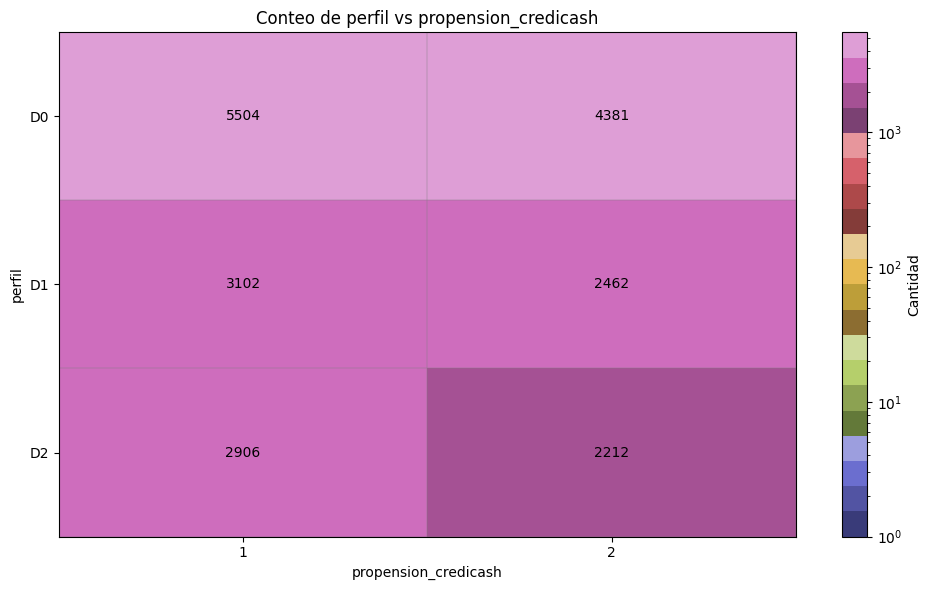

In [20]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
df_plot = (
    df_filtrado.groupBy("perfil", "propension_credicash")
    .count()
)

pdf = df_plot.toPandas()

pdf["propension_credicash"] = pdf["propension_credicash"].fillna("NULL").astype(str)
pdf["perfil"] = pdf["perfil"].fillna("NULL").astype(str)

tabla = pdf.pivot(index="perfil", columns="propension_credicash", values="count").fillna(0)
tabla = tabla.sort_index()
tabla = tabla.reindex(sorted(tabla.columns, key=lambda x: str(x)), axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

# im = ax.imshow(tabla.values, aspect="auto")
im = ax.imshow(
    tabla.values,
    aspect="auto",
    cmap="tab20b",
    norm=LogNorm(vmin=1, vmax=tabla.values.max())
)

ax.set_xticks(np.arange(-.5, len(tabla.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(tabla.index), 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.3)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_title("Conteo de perfil vs propension_credicash")
ax.set_xlabel("propension_credicash")
ax.set_ylabel("perfil")

ax.set_xticks(np.arange(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)
ax.set_yticks(np.arange(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# mostrar etiquetas dentro de cada celda
for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        ax.text(j, i, int(tabla.iloc[i, j]), ha="center", va="center")

plt.colorbar(im, ax=ax, label="Cantidad")
plt.tight_layout()
plt.show()

In [56]:
spark.stop()

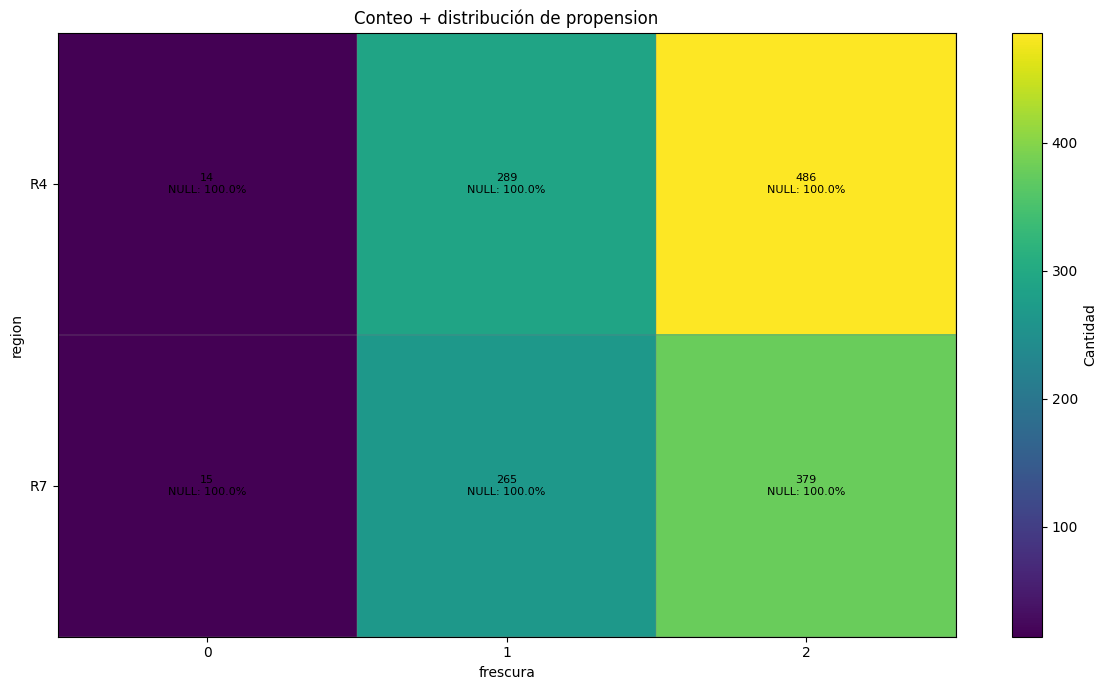

In [15]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 1) AGRUPAR POR 3 VARIABLES
# =====================================================
df_plot = (
    df_filtrado
    .groupBy(
        "region",
        "frescura",
        "propension"
    )
    .count()
)

pdf = df_plot.toPandas()

pdf["region"] = pdf["region"].fillna("NULL").astype(str)
pdf["frescura"] = pdf["frescura"].fillna("NULL").astype(str)
pdf["propension"] = pdf["propension"].fillna("NULL").astype(str)

# =====================================================
# 2) TOTAL POR PRODUCTO + PROPENSION
# =====================================================
pdf["total_celda"] = pdf.groupby(
    ["region", "frescura"]
)["count"].transform("sum")

pdf["pct"] = pdf["count"] / pdf["total_celda"] * 100

# =====================================================
# 3) TABLA DE VOLUMEN TOTAL
# =====================================================
tabla = pdf.pivot_table(
    index="region",
    columns="frescura",
    values="total_celda",
    aggfunc="max"
).fillna(0)

tabla = tabla.sort_index()
tabla = tabla.reindex(sorted(tabla.columns, key=lambda x: str(x)), axis=1)

# =====================================================
# 4) GRAFICAR
# =====================================================
fig, ax = plt.subplots(figsize=(12, 7))

im = ax.imshow(tabla.values, aspect="auto")

ax.set_title("Conteo + distribución de propension")
ax.set_xlabel("frescura")
ax.set_ylabel("region")

ax.set_xticks(np.arange(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)

ax.set_yticks(np.arange(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# grilla
ax.set_xticks(np.arange(-.5, len(tabla.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(tabla.index), 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.3)
ax.tick_params(which="minor", bottom=False, left=False)

# =====================================================
# 5) TEXTO DENTRO DE CADA CELDA
# =====================================================
for i, producto in enumerate(tabla.index):
    for j, propension in enumerate(tabla.columns):

        total = int(tabla.loc[producto, propension])

        subset = pdf[
            (pdf["region"] == producto) &
            (pdf["frescura"] == propension)
        ]

        texto_estados = "\n".join(
            subset.apply(
                lambda x: f"{x['propension']}: {x['pct']:.1f}%",
                axis=1
            )
        )

        texto = f"{total}\n{texto_estados}"

        ax.text(
            j, i,
            texto,
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(im, ax=ax, label="Cantidad")
plt.tight_layout()
plt.show()

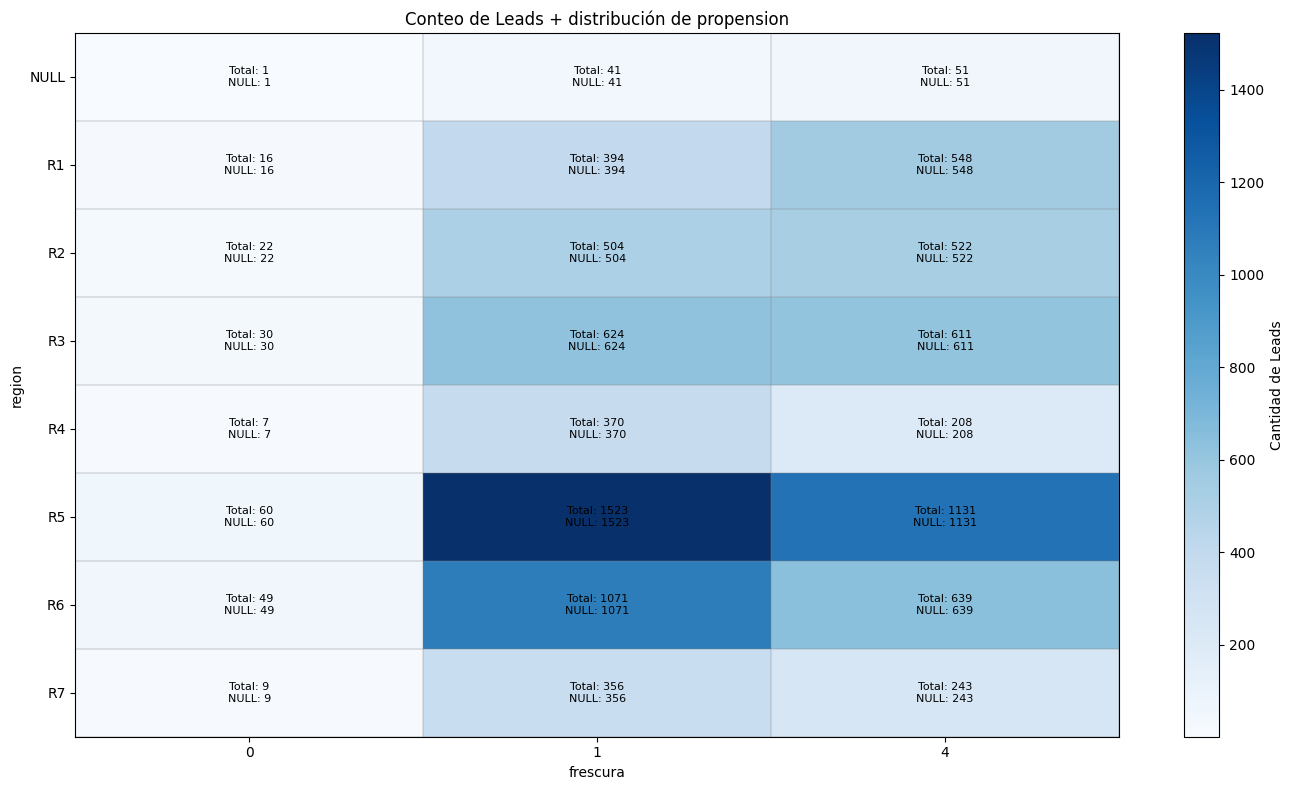

In [28]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 1) AGRUPAR POR 3 VARIABLES
# =====================================================
df_plot = (
    df_filtrado
    .groupBy(
        "region",
        "frescura",
        "propension"
    )
    .count()
)

pdf = df_plot.toPandas()

# Manejo de nulos
pdf["region"] = pdf["region"].fillna("NULL").astype(str)
pdf["frescura"] = pdf["frescura"].fillna("NULL").astype(str)
pdf["propension"] = pdf["propension"].fillna("NULL").astype(str)

# =====================================================
# 2) TOTAL POR REGION + FRESCURA
# =====================================================
pdf["total_celda"] = pdf.groupby(
    ["region", "frescura"]
)["count"].transform("sum")

# =====================================================
# 3) TABLA PARA HEATMAP
# =====================================================
tabla = pdf.pivot_table(
    index="region",
    columns="frescura",
    values="total_celda",
    aggfunc="max"
).fillna(0)

tabla = tabla.sort_index()
tabla = tabla.reindex(
    sorted(tabla.columns, key=lambda x: str(x)),
    axis=1
)

# =====================================================
# 4) GRAFICAR
# =====================================================
fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(
    tabla.values,
    aspect="auto",
    cmap="Blues"
)

ax.set_title("Conteo de Leads + distribución de propension")
ax.set_xlabel("frescura")
ax.set_ylabel("region")

ax.set_xticks(np.arange(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)

ax.set_yticks(np.arange(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# =====================================================
# 5) GRID
# =====================================================
ax.set_xticks(
    np.arange(-.5, len(tabla.columns), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-.5, len(tabla.index), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="gray",
    linestyle="-",
    linewidth=0.3
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

# =====================================================
# 6) TEXTO DENTRO DE CADA CELDA
# =====================================================
for i, region in enumerate(tabla.index):

    for j, frescura in enumerate(tabla.columns):

        total = int(tabla.loc[region, frescura])

        subset = pdf[
            (pdf["region"] == region) &
            (pdf["frescura"] == frescura)
        ]

        # Texto por propension mostrando cantidad de leads
        texto_propension = "\n".join(
            subset.sort_values("propension").apply(
                lambda x: f"{x['propension']}: {int(x['count'])}",
                axis=1
            )
        )

        texto = f"Total: {total}\n{texto_propension}"

        ax.text(
            j,
            i,
            texto,
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

# =====================================================
# 7) COLORBAR
# =====================================================
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Cantidad de Leads")

plt.tight_layout()
plt.show()

In [ ]:
df_list.groupBy('frescura') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+--------+-----+
|frescura|count|
+--------+-----+
|4       |8251 |
|3       |2839 |
|2       |1607 |
|1       |1231 |
+--------+-----+



In [21]:
df_filtrado.groupBy('mejor15_descripcion_cli') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+-------------------------------------------------+-----+
|mejor15_descripcion_cli                          |count|
+-------------------------------------------------+-----+
|DISCADOR                                         |16601|
|NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO       |2110 |
|CORTA LLAMADA                                    |1927 |
|BRINDARÁ INFORMACIÓN A TITULAR                   |447  |
|DERIVA A CASILLA DE VOZ                          |299  |
|NO BRINDARÁ INFORMACIÓN A TITULAR                |267  |
|NO CONTESTAN                                     |248  |
|NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES|156  |
|YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD            |107  |
|NULL                                             |97   |
|TELÉFONO APAGADO                                 |92   |
|ALFIN NO TIENE SUCURSAL CERCA                    |16   |
|NO CONOCE ALFIN BANCO                            |1    |
+-------------------------------------------------+-----+



In [7]:
df_list=df_list.filter(F.col('mejor_estado_tipi_telf').isNotNull())

In [6]:
df_list.groupBy('mejor_estado_tipi_telf') \
    .count() \
    .orderBy('mejor_estado_tipi_telf') \
    .show(30)


+----------------------+------+
|mejor_estado_tipi_telf| count|
+----------------------+------+
|                  NULL|657327|
|     CONTACTO EFECTIVO| 13828|
|      CONTACTO TERCERO|  1798|
|           NO CONTACTO|  3127|
+----------------------+------+



In [8]:
df_list.count()

18753

In [ ]:
['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'indice', 'deuda', 'tip_prioridad', 'Zona', 'perfil_ic', 'canal_asignado', 'marca', 'fecha_envio', 'retiro', 'region', 'prioridada', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'ult_estado_tipi_cli', 'ult_descripcion_cli', 'ult_sub_descripcion_cli', 'ult_peso_cli', 'mejor_estado_tipi_telf', 'mejor_descripcion_telf', 'mejor_sub_descripcion_telf', 'mejor_peso_telf']

['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'indice', 'deuda', 'tip_prioridad', 'Zona', 'perfil_ic', 'canal_asignado', 'marca', 'fecha_envio', 'retiro', 'region', 'prioridada', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'ult_estado_tipi_cli', 'ult_descripcion_cli', 'ult_sub_descripcion_cli', 'ult_peso_cli', 'mejor_estado_tipi_telf', 'mejor_descripcion_telf', 'mejor_sub_descripcion_telf', 'mejor_peso_telf']


In [9]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

w = Window.partitionBy('mejor_estado_tipi_telf').orderBy(F.rand())

df_split = df_list.withColumn("grupo_split", F.ntile(3).over(w))

df_parte_1 = df_split.filter(F.col("grupo_split") == 1).drop("grupo_split")
df_parte_2 = df_split.filter(F.col("grupo_split") == 2).drop("grupo_split")
df_parte_3 = df_split.filter(F.col("grupo_split") == 3).drop("grupo_split")
df_parte_4 = df_split.filter(F.col("grupo_split") == 4).drop("grupo_split")
df_parte_5 = df_split.filter(F.col("grupo_split") == 5).drop("grupo_split")
df_parte_6 = df_split.filter(F.col("grupo_split") == 6).drop("grupo_split")
df_parte_7 = df_split.filter(F.col("grupo_split") == 7).drop("grupo_split")

print(
    df_parte_1.count(),
    df_parte_2.count(),
    df_parte_3.count(),
    df_parte_4.count(),
    df_parte_5.count(),
    df_parte_6.count(),
    df_parte_7.count()
)

6253 6250 6250 0 0 0 0


In [ ]:
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutvo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro']prope
v

In [19]:
from pyspark.sql.window import Window

window_agencia = Window.partitionBy('region',"tienda_ir")

df_final = df_filtrado.withColumn(
    "cnt_agencia",
    F.count("*").over(window_agencia)
)
df_final=df_final.filter(
    F.col("cnt_agencia") > 100
)
print(df_final.count())


4122


In [ ]:
import os

def exportar_excel(df, columnas, ruta_base, nombre_archivo):
    """
    df: DataFrame de PySpark
    columnas: lista de columnas a seleccionar
    ruta_base: carpeta donde guardar
    nombre_archivo: nombre del archivo (sin extensión opcional)
    """
    
    df_filtrado = df.select(*columnas).toPandas()
    
    ruta = os.path.join(ruta_base, f"{nombre_archivo}.xlsx")
    
    df_filtrado.to_excel(ruta, index=False)
    
    print(f"Archivo guardado en: {ruta}")

In [ ]:
['dni_cliente', 'cabecera_carga', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro', 'lote_01', 'id', 'NUMERO_DOCUMENTO']reg

['dni_cliente', 'cabecera_carga', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash'

In [10]:
df_list_filtrada = df_parte_1.select(
    'vendor_lead_code', 'phone_number', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'df_parte_1.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [12]:
df_list_filtrada = df_parte_3.select(
    'vendor_lead_code', 'phone_number', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'df_parte_3.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [ ]:
['dni_cliente', 'cabecera_carga', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro', 'lote_01']

['dni_cliente', 'cabecera_carga', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash'

In [15]:
producto_externo=[
 'CREDICASH',
 'CREDICASH R / ELECTRO',
 ]
# producto_externo=['CREDICASH R / ELECTRO MSI', 'CREDICASH R / ELECTRO', 'CREDICASH R', 'CREDICASH / ELECTRO', 'CREDICASH', 'CREDICASH / ELECTRO MSI']


['CREDICASH']

In [20]:
df_list_filtrada = df_filtrado.select(
    'cabecera_carga',
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'cregfhxxx__1.csv')

import csv

df_list_filtrada.to_csv(
    ruta_archivo,
    index=False,
    sep=",",
    header=False,
    encoding="latin-1", 
    lineterminator="\r\n"
)


df_list_filtrada.count()

cabecera_carga    7873
dtype: int64

In [ ]:
producto_externo=[
    'CREDICASH R / ELECTRO MSI',
 'CREDICASH R / ELECTRO',
 'CREDICASH',
 ]



In [15]:
df_filtrado.groupBy('producto_externo') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+-----------------------+-----+
|producto_externo       |count|
+-----------------------+-----+
|CREDICASH / ELECTRO    |5077 |
|CREDICASH / ELECTRO MSI|3908 |
|CREDICASH              |889  |
+-----------------------+-----+



In [40]:
df_filtrado.groupBy('producto_externo') \
    .count() \
    .orderBy('producto_externo') \
    .show(30, truncate=False)

+-------------------------+-----+
|producto_externo         |count|
+-------------------------+-----+
|CREDICASH / ELECTRO      |5416 |
|CREDICASH / ELECTRO MSI  |2079 |
|CREDICASH R / ELECTRO    |156  |
|CREDICASH R / ELECTRO MSI|27   |
+-------------------------+-----+



In [ ]:
producto_externo=[
    'CREDICASH R / ELECTRO MSI',
 'CREDICASH R / ELECTRO',
 'CREDICASH R',
 'CREDICASH / ELECTRO',
 'CREDICASH',
 ]


In [ ]:

df_dni = df_filtrado.toPandas()

import os

ruta_archivo = os.path.join(ruta_csv, 'credicash_.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [11]:
print([row['perfil' ] for row in df_list.select('perfil').distinct().collect()])


['O1', 'D1', 'O2', 'O3', 'D2', 'D0']


['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'AUTODIAL NO RESPONDE (AUTO)', 'OCUPADO (AUTO)', 'GESTION EN PROCESO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'AGENTE NO DISPONIBLE (AUTO)']


In [ ]:

exportar_lista(df_filtrado,'tc_cenco_2026033014.xlsx','linea_cencosud')

In [50]:
cantidad_leads=df_filtrado.count()

In [56]:
info_list=f"""
Se tienen {cantidad_leads} leads
Prioridad : {quintil}
maximo de intentos por num telef: {q_intentos_telef}
flg_ex_cliente :{flg_ex_cliente}
{segmento}
{first_name}

"""

print(info_list)


Se tienen 2814 leads
Prioridad : ['1', '2']
maximo de intentos por num telef: 40
flg_ex_cliente :['NUEVO']
['TC2', 'TC1']
['SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']




In [79]:
exportar_lista(df_filtrado,'tc_cencor_202603310847.xlsx','linea_cencosud')

['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'NUMERO DESCONECTADO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [ ]:
import os

ruta_archivo = os.path.join(ruta_csv, 'ivr_202603271706.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [142]:

df_dni = df_filtrado.toPandas()


In [73]:
los pu pm los qu epodemos usar


SyntaxError: invalid syntax (2290498890.py, line 1)

In [12]:

nombre_archivo_xlsx='SAE_202603251722.xlsx'
columna_ref='linea_sae'
exportar_lista(df_filtrado,nombre_archivo_xlsx,columna_ref)


In [ ]:
fecha_mes_base='2026-03-01'
t_maestra='Base_Maestra_Cencosud_PPFF'
t_name_vigente='Base_Maestra_Cencosud_PPFF_vigente'
t_mumeros='tNumeroCenco_Sae'
cols_drop=[ 'FRESCURA_TARGET', 'REP1', 'REP2', 'REP3','FLAT2']


In [97]:
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
)
df_dni = df_filtrado.toPandas()

In [ ]:
import matplotlib.pyplot as plt

df_dni['email'].value_counts().plot(kind='bar')

plt.title('Top departamentos (email)')
plt.xlabel('Departamento')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

In [8]:
df_list.select('retiro_01').filter(col('retiro_01')==0).count()

2266

In [13]:
# print([row['first_name'] for row in df_list.select('first_name').distinct().collect()])
# print([row['title'] for row in df_list.select('title').distinct().collect()])
# print([row['tip_prioridad'] for row in df_list.select('tip_prioridad').distinct().collect()])
# print([row['email'] for row in df_list.select('email').distinct().collect()])
# print([row['prioridada'] for row in df_list.select('prioridada').distinct().collect()])
print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])
# print(df_list.columns)


['PERSONA FALLECIDA', 'VOLVER A LLAMAR', 'LO VA A PENSAR', 'DESEA ELECTRO', 'NEGOCIO EN ZONA NO COBERTURADA', 'TITULAR CONTAGIADO CON COVID - 19', 'CREDITO CONCRETADO', 'MENSAJES CON TERCEROS - HIJOS', 'NO DESEA SER CONTACTADO / MANIFIESTA SU RECHAZO', 'NO NECESITA / NO DESEA', 'TELEFONO APAGADO', 'NUMERO EQUIVOCADO', 'ESTA ENDEUDADO', 'MENSAJES CON TERCEROS - ESPOSA', 'OTROS', 'NO CONTESTA ', 'TITULAR NO CALIFICA- GIRO RESTRINGIDO9', 'CLIENTE RECHAZADO', 'MENSAJES CON TERCEROS - OTROS', 'NO BRINDA CONSENTIMIENTO', 'CASA EN ZONA NO COBERTURADA', 'SI QUIERE', 'CLIENTE DE VIAJE', 'TELEFONO FUERA DE SERVICIO/SUSPENDIDO', 'CONFIRMAR CITA', 'INTERESES ELEVADOS', 'NUMERO NO EXISTE', 'TITULAR NO CALIFICA - DESEMPLEO', 'MENSAJES DE TEXTO', 'TONO OCUPADO', 'SOLICITA SER RETIRADO', 'IVR - NO CONFIRMA', 'MALA EXPERIENCIA (TDA/FNC)', 'DESEA MAS MONTO', 'NO QUIERE', None]
